# Análisis ConnectaTel

Como **analista de datos**, tu objetivo es evaluar el **comportamiento de los clientes** de una empresa de telecomunicaciones en Latinoamérica, ConnectaTel. 

Trabajaremos con información registrada **hasta el año 2024**, lo cual permitirá analizar el comportamiento del negocio dentro de ese periodo.

Para ello trabajarás con tres datasets:  

- **plans.csv** → información de los planes actuales (precio, minutos incluidos, GB incluidos, costo por extra)  
- **users.csv** → información de los clientes (edad, ciudad, fecha de registro, plan, churn)  
- **usage.csv** → detalle del **uso real** de los servicios (llamadas y mensajes)  

Deberás **explorar**, **limpiar** y **analizar** estos datos para construir un **perfil estadístico** de los clientes, detectar **comportamientos atípicos** y crear **segmentos de clientes**.  

Este análisis te permitirá **identificar patrones de consumo**, **diseñar estrategias de retención** y **sugerir mejoras en los planes** ofrecidos por la empresa.

> 💡 Antes de empezar, recuerda pensar de forma **programática**: ¿qué pasos necesitas? ¿En qué orden? ¿Qué quieres medir y por qué?


--- 
## 🧩 Paso 1: Cargar y explorar

Antes de limpiar o combinar los datos, es necesario **familiarizarte con la estructura de los tres datasets**.  
En esta etapa, validarás que los archivos se carguen correctamente, conocerás sus columnas y tipos de datos, y detectarás posibles inconsistencias.

### 1.1 Carga de datos y vista rápida

**🎯 Objetivo:**  
Tener los **3 datasets listos en memoria**, entender su contenido y realizar una revisión preliminar.

**Instrucciones:**  
- Importa las librerías necesarias (por ejemplo `pandas`, `seaborn`, `matplotlib.pyplot`)
- Carga los archivos CSV usando `pd.read_csv()`:
  - **`/datasets/plans.csv`**  
  - **`/datasets/users_latam.csv`**  
  - **`/datasets/usage.csv`**  
- Guarda los DataFrames en las variables: `plans`, `users`, `usage`.  
- Muestra las primeras filas de cada DataFrame usando `.head()`.


In [130]:
# importar librerías
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [131]:
# cargar archivos
plans = pd.read_csv('/datasets/plans.csv')
users = pd.read_csv('/datasets/users_latam.csv')
usage = pd.read_csv('/datasets/usage.csv')

In [132]:
plans.head()

,plan_name,messages_included,gb_per_month,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute
0,Basico,100,5,100,12,1.2,0.08,0.10
1,Premium,500,20,600,25,1.0,0.05,0.07


In [133]:
users.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,Mateo,Torres,53,?,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN


In [134]:
usage.head()

,id,user_id,type,date,duration,length
0,1,10332,call,2024-01-01 00:00:00.000000000,0.09,NaN
1,2,11458,text,2024-01-01 00:06:30.969774244,NaN,39.0
2,3,11777,text,2024-01-01 00:13:01.939548488,NaN,36.0
3,4,10682,call,2024-01-01 00:19:32.909322733,1.53,NaN
4,5,12742,call,2024-01-01 00:26:03.879096977,4.84,NaN


**Tip:** Si no usas `print()` la tabla se vera mejor.

### 1.2 Exploración de la estructura de los datasets

**🎯 Objetivo:**  
Conocer la **estructura de cada dataset**, revisar cuántas filas y columnas tienen, identificar los **tipos de datos** de cada columna y detectar posibles **inconsistencias o valores nulos** antes de iniciar el análisis.

**Instrucciones:**  
- Revisa el **número de filas y columnas** de cada dataset usando `.shape`.  
- Usa `.info()` en cada DataFrame para obtener un **resumen completo** de columnas, tipos de datos y valores no nulos.  

In [135]:
# revisar el número de filas y columnas de cada dataset
print("plans", plans.shape)
print("users", users.shape)
print("usage", usage.shape)

plans (2, 8)
users (4000, 8)
usage (40000, 6)


In [136]:
# inspección de plans con .info()
plans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   plan_name          2 non-null      object 
 1   messages_included  2 non-null      int64  
 2   gb_per_month       2 non-null      int64  
 3   minutes_included   2 non-null      int64  
 4   usd_monthly_pay    2 non-null      int64  
 5   usd_per_gb         2 non-null      float64
 6   usd_per_message    2 non-null      float64
 7   usd_per_minute     2 non-null      float64
dtypes: float64(3), int64(4), object(1)
memory usage: 256.0+ bytes


In [137]:
# inspección de users con .info()
users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     4000 non-null   int64 
 1   first_name  4000 non-null   object
 2   last_name   4000 non-null   object
 3   age         4000 non-null   int64 
 4   city        3531 non-null   object
 5   reg_date    4000 non-null   object
 6   plan        4000 non-null   object
 7   churn_date  466 non-null    object
dtypes: int64(2), object(6)
memory usage: 250.1+ KB


In [138]:
# inspección de usage con .info()
usage.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        40000 non-null  int64  
 1   user_id   40000 non-null  int64  
 2   type      40000 non-null  object 
 3   date      39950 non-null  object 
 4   duration  17924 non-null  float64
 5   length    22104 non-null  float64
dtypes: float64(2), int64(2), object(2)
memory usage: 1.8+ MB


---

## 🧩Paso 2: Identificación de problemas de calidad de datos

### 2.1 Revisión de valores nulos

**🎯 Objetivo:**  
Detectar la presencia y magnitud de valores faltantes para evaluar si afectan el análisis o requieren imputación/eliminación.

**Instrucciones:**  
- Cuenta valores nulos por columna para cada dataset.
- Calcula la proporción de nulos por columna para cada dataset.

El dataset `plans` solamente tiene 2 renglones y se puede observar que no tiene ausentes, por ello no necesita exploración adicional.

<br>
<details>
<summary>Haz clic para ver la pista</summary>
Usa `.isna().sum()` para contar valores nulos y usa `.isna().mean()` para calcular la proporción.

In [139]:
# cantidad de nulos para users
print("VALORES NULOS POR COLUMNA")
print(users.isna().sum())
print("PROPORCION DE NULOS POR COLUMNA")
print(users.isna().mean()*100)

VALORES NULOS POR COLUMNA
user_id          0
first_name       0
last_name        0
age              0
city           469
reg_date         0
plan             0
churn_date    3534
dtype: int64
PROPORCION DE NULOS POR COLUMNA
user_id        0.000
first_name     0.000
last_name      0.000
age            0.000
city          11.725
reg_date       0.000
plan           0.000
churn_date    88.350
dtype: float64


In [140]:
print("VALORES NULOS POR COLUMNA")
print(usage.isna().sum())
print("PROPORCION DE NULOS POR COLUMNA")
print(usage.isna().mean()*100.0)

VALORES NULOS POR COLUMNA
id              0
user_id         0
type            0
date           50
duration    22076
length      17896
dtype: int64
PROPORCION DE NULOS POR COLUMNA
id           0.000
user_id      0.000
type         0.000
date         0.125
duration    55.190
length      44.740
dtype: float64



✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico al final del bloque. Incluye qué ves y que acción recomendarías para cada caso.

💡 **Nota:** Justifica tus decisiones brevemente (1 línea por caso).
* Hint:
 - Si una columna tiene **más del 80–90% de nulos**, normalmente se **ignora o elimina**.  
 - Si tiene **entre 5% y 30%**, generalmente se **investiga para imputar o dejar como nulos**.  
 - Si es **menor al 5%**, suele ser un caso simple de imputación o dejar como nulos. 
 
 ---

**Valores nulos**  
- ¿Qué columnas tienen valores faltantes y en qué proporción?
  * Para el dataframe users, las columnas que tienen valores faltantes son: Por un lado, city con 469 nulos, lo que equivale a una proporción del 11,725%. La otra columna con valores faltantes es churn_date, la cual tiene 3,534 datos faltantes, lo que equivale al 88,35%del total de datos.
  * Para el dataframe usage, las columnas que tienen valores faltantes son: date: 50 nulos (0.125%). duration: 22,076 nulos (55.19%). length: 17,896 nulos (44.74%).
      
- Indica qué harías: ¿imputar, eliminar, ignorar?
  * Para el caso del dataframe users, imputaria los datos de la columna city asociandolos a una categoria desconocida y para los datos de la columna churn_date, aunque tienen un valor nulo muy representativo no los eliminaria ya que el hecho de que tengan valores nulos indica que los usuarios siguen activos.
  * Para el caso del dataframe usage: 
    date: dejar nulos, ya que es menor al 5%.
    duration: Imputar teniendo un valor logico al determinar la relacion entre la media y la mediana para poder saber con cual valor realizar la imputacion, teninedo en consideracion si existen valores nulos en relacion con el tipo type call dado que los nulos asociados a type text no se deberian tener encuenta dado que no es logica la relacion.
    length: Imputar teniendo un valor logico al determinar la relacion entre la media y la mediana para poder saber con cual valor realizar la imputacion, teniendo en consideracion si existen valores nulos en relacion con el tipo type text dado que los nulos asociados a type call no se deberian tener encuenta dado que no es logica la relacion.


### 2.2 Detección de valores inválidos y sentinels

🎯 **Objetivo:**  
Identificar sentinels: valores que no deberían estar en el dataset.

**Instrucciones:**
- Explora las columnas numéricas con **un resumen estadístico** y describe brevemente que encontraste.
- Explora las columnas categóricas **relevantes**, revisando sus valores únicos y describe brevemente que encontraste.



El dataset `plans` solamente tiene 2 renglones, por ello no necesita exploración adicional.

In [141]:
# explorar columnas numéricas de users
users=pd.read_csv('/datasets/users_latam.csv')
print("RESUMEN ESTADISTICO PARA USERS")
users[['user_id','age']].describe()
#print("\nVALORES DUPLICADOS PARA LA COLUMNA USER_ID")
#users['user_id'].duplicated().sum()


RESUMEN ESTADISTICO PARA USERS


,user_id,age
count,4000.000000,4000.000000
mean,11999.500000,33.739750
std,1154.844867,123.232257
min,10000.000000,-999.000000
25%,10999.750000,32.000000
50%,11999.500000,47.000000
75%,12999.250000,63.000000
max,13999.000000,79.000000


- La columna user_id contiene 4.000 registros, con identificadores que van desde 10.000 hasta 13.999. No se identifican valores duplicados, lo que indica que cada user_id corresponde a un único registro.

Por lo tanto, la columna presenta una estructura consistente para funcionar como identificador único de los usuarios y no se evidencian problemas de duplicidad en los registros analizados.

- En la columna age encontramos 4.000 registros, con una edad promedio de 33,739 años. La desviación estándar presenta un valor de 123,232 años, considerablemente alto en comparación con los valores observados en los cuartiles, lo que evidencia una aparente dispersión significativa de los datos.

Sin embargo, al revisar los valores mínimo y máximo, encontramos que la edad mínima corresponde a -999 años, mientras que la máxima es de 79 años. El valor de -999 corresponde a un valor sentinel, utilizado para representar posiblemente información faltante, desconocida o no disponible.

Este valor está afectando las medidas estadísticas, especialmente la media y la desviación estándar, generando una percepción de dispersión mucho mayor a la que realmente presentan las edades de los usuarios.

Adicionalmente, los cuartiles muestran que el 50 % de los usuarios tiene una edad de 47 años o menos, mientras que el 75 % tiene una edad de 63 años o menos. Esto indica que, excluyendo el valor anómalo, la distribución de edades se encuentra dentro de un rango aparentemente razonable.

In [142]:
# explorar columnas numéricas de usage
usage=pd.read_csv('/datasets/usage.csv')
usage[['id','user_id','duration','length']].describe()
#print("\nVALORES DUPLICADOS PARA LA COLUMNA ID")
#usage['id'].duplicated().sum()
#print("\nAGRUPAMIENTO DE DATOS PARA VERIFICACION")
#usage.groupby('type')[['duration','length']].count()
#print("\nVALORES DUPLICADOS PARA LA COLUMNA USER_ID")
#usage['user_id'].duplicated().sum()

,id,user_id,duration,length
count,40000.00000,40000.000000,17924.000000,22104.000000
mean,20000.50000,12002.405975,5.202237,52.127398
std,11547.14972,1157.279564,6.842701,56.611183
min,1.00000,10000.000000,0.000000,0.000000
25%,10000.75000,10996.000000,1.437500,37.000000
50%,20000.50000,12013.000000,3.500000,50.000000
75%,30000.25000,13005.000000,6.990000,64.000000
max,40000.00000,13999.000000,120.000000,1490.000000


-La columna id contiene 40.000 registros y no presenta valores duplicados, por lo que funciona correctamente como identificador único de las interacciones.
-La columna user_id presenta múltiples registros repetidos. Esto no necesariamente representa un error, ya que un mismo usuario puede realizar varias llamadas o enviar múltiples mensajes. Se identifican aproximadamente 3.999 usuarios únicos con una sola interaccion.
-Las columnas duration y length presentan una cantidad considerable de valores faltantes. Estos valores deben analizarse de acuerdo con el tipo de interacción, ya que una llamada debería contener información de duración y un mensaje debería contener información sobre su longitud.
-Se identificaron 28 registros inconsistentes en los que simultáneamente aparecen valores en duration y length: 12 correspondientes a llamadas y 16 a mensajes. Estos registros deberían revisarse, ya que cada tipo de interacción debería contener únicamente la información técnica correspondiente.
-Se observan valores mínimos de 0 tanto en duration como en length. Es necesario determinar si representan interacciones válidas o registros incorrectos.
-La columna duration presenta una media de aproximadamente 5,2 minutos y una mediana de 3,5 minutos, además de un máximo de 120 minutos. La diferencia entre media y mediana puede indicar la presencia de valores extremos.
-La columna length presenta una media cercana a 52 caracteres y una mediana de 50, pero alcanza un máximo de 1.490 caracteres. Este valor debe analizarse como posible valor atípico.

In [143]:
# explorar columnas categóricas de users
#columnas_user = ['city', 'plan']
import pandas as pd
users = pd.read_csv('/datasets/users_latam.csv')
print("VALORES UNICOS PARA CIUDAD")
print(users['city'].unique())
print("VALORES UNICOS PARA PLAN")
print(users['plan'].unique())
users[['city','plan']].describe()

VALORES UNICOS PARA CIUDAD
['Medellín' '?' 'CDMX' 'Bogotá' 'GDL' 'MTY' nan 'Cali']
VALORES UNICOS PARA PLAN
['Basico' 'Premium']


,city,plan
count,3531,4000
unique,7,2
top,Bogotá,Basico
freq,808,2595


-La columna city presenta 7 categorías diferentes entre los valores registrados. Bogotá es la ciudad con mayor frecuencia, con 808 registros.
-Se identifican 469 valores faltantes en city, equivalentes aproximadamente al 11,7 % de los 4.000 registros.
-Se encuentra el valor ?, el cual seria un valor sentinel para representar información desconocida.
-Se observa falta de estandarización en los nombres de las ciudades, debido a la combinación de nombres completos y abreviaturas como CDMX, GDL y MTY. Se recomienda homologar estas categorías.
-La columna plan no presenta valores faltantes y contiene únicamente dos categorías: Basic y Premium.
-El plan Basic es predominante, con 2.595 usuarios, aproximadamente el 64,9 % de la base.

In [144]:
# explorar columna categórica de usage
import pandas as pd
usage = pd.read_csv('/datasets/usage.csv')
usage[['type']].describe()

,type
count,40000
unique,2
top,text
freq,22092


- La columna `type` contiene 2 categorías, siendo “text” la categoría predominante, con 22.092 registros de 40.000, aproximadamente 55,2 %. La distribución entre las dos categorías parece relativamente equilibrada.


---
✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico. Incluye qué ves y que acción recomendarías para cada caso. 

**Valores inválidos o sentinels**  
¿En qué columnas encontraste valores inválidos o sentinels? ¿Qué acción tomarías?
Se identificaron valores inválidos o sentinels principalmente en las columnas age y city:
age: se encontró el valor -999, que no corresponde a una edad válida y funciona como un valor sentinel para representar información faltante o desconocida. La acción recomendada sería reemplazar -999 por NaN y posteriormente decidir si los valores faltantes se imputan o se mantienen como nulos, dependiendo del análisis. En este caso, para evitar distorsionar la media y la desviación estándar, primero se debe convertir -999 en NaN.
city: se identificó el valor ?, que representa información desconocida y puede considerarse un sentinel. La acción sería reemplazar ? por NaN y posteriormente analizar los valores faltantes. También sería conveniente homologar los nombres de las ciudades, ya que existen abreviaturas como CDMX, GDL y MTY.
Además, aunque no necesariamente son sentinels, se encontraron valores de 0 en duration y length que requieren revisión para determinar si representan interacciones válidas o datos incorrectos.

### 2.3 Revisión y estandarización de fechas

**🎯 Objetivo:**  
Asegurar que las columnas de fecha estén correctamente formateadas y detectar años fuera de rango que indiquen errores de captura.

**Instrucciones:**  
- Convierte las columnas de fecha a tipo fecha y asegurate de que el código sea a prueba de errores.  
- Revisa cuántas veces aparece cada año.
- Identifica fechas imposibles (ej. años futuros o negativos).

Toma en cuenta que tenemos datos registrados hasta el año 2024.

In [145]:
# Convertir a fecha la columna `reg_date` de users
import pandas as pd
users=pd.read_csv('/datasets/users_latam.csv')
users['reg_date'] = pd.to_datetime(users["reg_date"], errors="coerce")
users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   user_id     4000 non-null   int64         
 1   first_name  4000 non-null   object        
 2   last_name   4000 non-null   object        
 3   age         4000 non-null   int64         
 4   city        3531 non-null   object        
 5   reg_date    4000 non-null   datetime64[ns]
 6   plan        4000 non-null   object        
 7   churn_date  466 non-null    object        
dtypes: datetime64[ns](1), int64(2), object(5)
memory usage: 250.1+ KB


In [146]:
# Convertir a fecha la columna `date` de usage
import pandas as pd
usage=pd.read_csv('/datasets/usage.csv')
usage['date']=pd.to_datetime(usage["date"], errors="coerce")
usage.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   id        40000 non-null  int64         
 1   user_id   40000 non-null  int64         
 2   type      40000 non-null  object        
 3   date      39950 non-null  datetime64[ns]
 4   duration  17924 non-null  float64       
 5   length    22104 non-null  float64       
dtypes: datetime64[ns](1), float64(2), int64(2), object(1)
memory usage: 1.8+ MB


In [147]:
# Revisar los años presentes en `reg_date` de users
print(users["reg_date"].dt.year.value_counts().sort_index())

2022    1314
2023    1316
2024    1330
2026      40
Name: reg_date, dtype: int64


se presenta informacion generada para el año 2026 saltandose el año 2025, a su ves es necesario recordar que inicialmente nos manifestaban que se tenian registros hasta el año 2024 por ende es incoherente que aparezca informacion para años subsiguientes al año 2024.

In [148]:
# Revisar los años presentes en `date` de usage
print(usage["date"].dt.year.value_counts().sort_index())

2024.0    39950
Name: date, dtype: int64


En este dataframe solamente se encuentran registros del año 2024, se evidencia 50 datos faltantes.

✍️ **Comentario**: escribe tu diagnóstico, e incluye **qué acción recomendarías** para cada caso:

**Fechas fuera de rango**  
- ¿Aparecen años imposibles? (años muy viejos o sin transcurrir al momento de guardar los datos)
- ¿Qué harías con ellas?
  En el DataFrame users se identifican registros correspondientes al año 2026. Este año resulta inconsistente con la información proporcionada inicialmente, según la cual los datos deberían contener registros únicamente hasta el año 2024. Por lo tanto, los registros de 2026 deben considerarse como datos inválidos o inconsistentes y requieren una revisión para determinar si corresponden a un error en los datos o en el proceso de registro. No se recomienda eliminarlos inmediatamente; primero se debería verificar su origen y, si se confirma que son incorrectos, convertirlos en valores nulos o excluirlos del análisis según el caso.

Por otro lado, en usage los registros corresponden al año 2024, por lo que no se evidencian años posteriores al periodo esperado. Los 50 valores faltantes deben mantenerse como nulos mientras se determina si pueden recuperarse a partir de otras variables

---

## 🧩Paso 3: Limpieza básica de datos

### 3.1 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Aplicar reglas de limpieza para reemplazar valores sentinels y corregir fechas imposibles.

**Instrucciones:**  
- En `age`, reemplaza el sentinel **-999** con la mediana.
- En `city`, reemplaza el sentinel `"?"` por valores nulos (`pd.NA`).  
- Marca como nulas (`pd.NA`) las fechas fuera de rango.

In [149]:
# Reemplazar -999 por la mediana de age
age_mediana=users["age"].median()
print("La mediana de age es:",age_mediana)
users["age"]=users["age"].replace(-999,age_mediana)
# Verificar cambios
users['age'].describe()

La mediana de age es: 47.0


count    4000.000000
mean       48.122250
std        17.690408
min        18.000000
25%        33.000000
50%        47.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64

In [150]:
# Reemplazar ? por NA en city
users["city"]=users["city"].replace("?",np.nan)
users["city"] = users["city"].astype(object).where(users["city"].notna(), np.nan)
# Verificar cambios
print("VALORES UNICOS PARA CIUDAD")
print(users['city'].unique())

VALORES UNICOS PARA CIUDAD
['Medellín' nan 'CDMX' 'Bogotá' 'GDL' 'MTY' 'Cali']


In [151]:
# Marcar fechas futuras como NA para reg_date
ano_limite=2024
users.loc[users["reg_date"].dt.year>ano_limite,"reg_date"]=np.nan
# Verificar cambios
print(users["reg_date"].dt.year.value_counts().sort_index())

2022.0    1314
2023.0    1316
2024.0    1330
Name: reg_date, dtype: int64


### 3.2 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Decidir qué hacer con los valores nulos según su proporción y relevancia.

**Instrucciones:**
- Verifica si los nulos en `duration` y `length` son **MAR**(Missing At Random) revisando si dependen de la columna `type`.  
  Si confirmas que son MAR, **déjalos como nulos** y justifica la decisión.

In [152]:
# Verificación MAR en usage (Missing At Random) para duration
print(usage.groupby("type")["duration"].apply(lambda x: x.isna().mean() * 100))

type
call     0.000000
text    99.927576
Name: duration, dtype: float64


In [153]:
# Verificación MAR en usage (Missing At Random) para length
print(usage.groupby("type")["length"].apply(lambda x: x.isna().mean() * 100))

type
call    99.932991
text     0.000000
Name: length, dtype: float64


Al realizar el análisis MAR, observamos que los valores nulos de duration y length dependen claramente de la variable type. Para duration, el 99.92% de los registros de tipo text presentan valores nulos, mientras que para call no hay valores nulos. Por otro lado, para length, el 99.93% de los registros de tipo call presentan valores nulos, mientras que para text no hay valores nulos.
Este patrón tiene sentido según el tipo de registro, ya que cada variable contiene información relevante para un tipo específico de uso. Por lo tanto, consideramos que los valores faltantes son MAR y no debemos imputarlos, ya que los nulos son esperados y tienen un significado dentro de la estructura de los datos.

In [154]:
usage.loc[usage["type"]=="text", "duration"]=np.nan
usage.loc[usage["type"]=="call","length"]=np.nan
print(usage.groupby("type")["duration"].apply(lambda x: x.isna().mean() * 100))
print(usage.groupby("type")["length"].apply(lambda x: x.isna().mean() * 100))

type
call      0.0
text    100.0
Name: duration, dtype: float64
type
call    100.0
text      0.0
Name: length, dtype: float64


---

## 🧩Paso 4: Summary statistics de uso por usuario


### 4.1 Agrupación por comportamiento de uso

🎯**Objetivo**: Resumir las variables clave de la tabla `usage` **por usuario**, creando métricas que representen su comportamiento real de uso histórico. 

**Instrucciones:**: 
1. Construye una tabla agregada de `usage` por `user_id` que incluya:
- número total de mensajes  
- número total de llamadas  
- total de minutos de llamadas
- total de mensaje.

2. Renombra las columnas para que tengan nombres claros:  
- `cant_mensajes`  
- `cant_llamadas`  
- `cant_minutos_llamada`
3. Combina esta tabla con `users`.

In [155]:
# Columnas auxiliares
usage["is_text"]=(usage["type"]=="text").astype(int) #conocer el total de mensajes
usage["is_call"]=(usage["type"]=="call").astype(int) #conocer el total de llamadas
# Agrupar información por usuario
usage_agg=usage.groupby("user_id")["is_call","is_text","duration","length"].sum().reset_index()
# observar resultado
usage_agg.head(3)

,user_id,is_call,is_text,duration,length
0,10000,3,7,23.70,258.0
1,10001,10,5,33.18,226.0
2,10002,2,5,10.74,225.0


In [156]:
# Renombrar columnas
usage_agg=usage_agg.rename(columns={"is_call":"cant_llamadas","is_text":"cant_mensajes","duration":"cant_minutos_llamada","length":"Tamano_texto"})
# observar resultado
usage_agg.head(3)

,user_id,cant_llamadas,cant_mensajes,cant_minutos_llamada,Tamano_texto
0,10000,3,7,23.70,258.0
1,10001,10,5,33.18,226.0
2,10002,2,5,10.74,225.0


In [157]:
# Combinar la tabla agregada con el dataset de usuarios
user_profile=users.merge(usage_agg, on="user_id", how="left")
user_profile.head(5)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_llamadas,cant_mensajes,cant_minutos_llamada,Tamano_texto
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,3.0,7.0,23.70,258.0
1,10001,Mateo,Torres,53.0,NaN,2022-01-01 06:34:17.914478619,Basico,NaN,10.0,5.0,33.18,226.0
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,2.0,5.0,10.74,225.0
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,3.0,11.0,8.99,530.0
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,3.0,4.0,8.01,229.0


### 4.2 4.2 Resumen estadístico por usuario durante el 2024

🎯 **Objetivo:** Analizar las columnas numéricas y categóricas de los usuarios, para identificar rangos, valores extremos y distribución de los datos antes de continuar con el análisis.

**Instrucciones:**  
1. Para las columnas **numéricas** relevantes, obtén un resumen estadístico (media, mediana, mínimo, máximo, etc.).  
2. Para la columna **categórica** `plan`, revisa la distribución en **porcentajes** de cada categoría.

In [158]:
# Resumen estadístico de las columnas numéricas
users_2024=user_profile[user_profile["reg_date"].dt.year==2024]
columnas_numericas=[
    "cant_llamadas",
    "cant_mensajes",
    "cant_minutos_llamada",
    "Tamano_texto",
    "age"
]
users_2024[columnas_numericas].describe()


,cant_llamadas,cant_mensajes,cant_minutos_llamada,Tamano_texto,age
count,1330.000000,1330.000000,1330.000000,1330.000000,1330.000000
mean,4.557143,5.500000,23.314639,286.710526,48.414286
std,2.140329,2.382293,17.025665,170.559085,17.963443
min,0.000000,0.000000,0.000000,0.000000,18.000000
25%,3.000000,4.000000,11.302500,182.000000,33.000000
50%,4.000000,5.000000,20.185000,269.500000,48.000000
75%,6.000000,7.000000,32.075000,359.000000,64.000000
max,13.000000,16.000000,155.690000,1996.000000,79.000000


In [159]:
# Distribución porcentual del tipo de plan
plan_porcentaje=users_2024["plan"].value_counts(normalize=True)*100
print(plan_porcentaje)

Basico     65.639098
Premium    34.360902
Name: plan, dtype: float64


---

## 🧩Paso 5: Visualización de distribuciones (uso y clientes) y outliers


### 5.1 Visualización de Distribuciones

🎯 **Objetivo:**  
Entender visualmente cómo se comportan las variables clave tanto de **uso** como de **clientes**, observar si existen diferencias según el tipo de plan, y analizar la **forma de la distribución**.

**Instrucciones:**  
Graficar **histogramas** para las siguientes columnas:  
- `age` (edad de los usuarios)
- `cant_mensajes`
- `cant_llamadas`
- `total_minutos_llamada` 

Después de cada gráfico, escribe un **insight** respecto al plan y la variable, por ejemplo:  
- "Dentro del plan Premium, hay mayor proporción de..."  
- "Los usuarios Básico tienden a hacer ... llamadas y enviar ... mensajes."  o "No existe algún patrón."
- ¿Qué tipo de distribución tiene ? (simétrica, sesgada a la derecha o a la izquierda) 

**Hint**  
Para cada histograma, 
- Usa `hue='plan'` para ver cómo varían las distribuciones según el plan (Básico o Premium).
- Usa `palette=['skyblue','green']`
- Agrega título y etiquetas

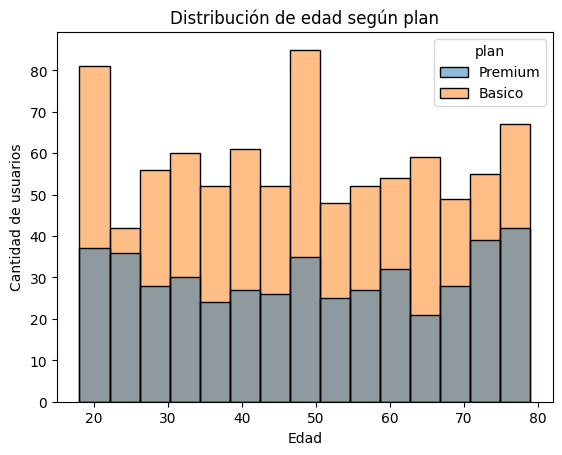

In [160]:
# Histograma para visualizar la edad (age)

import seaborn as sns
import matplotlib.pyplot as plt
sns.histplot(
    data=users_2024,
    x="age",
    hue="plan",
    bins=15
)
plt.title("Distribución de edad según plan")
plt.xlabel("Edad")
plt.ylabel("Cantidad de usuarios")
plt.show()

💡Insights: 
- Insight: No existe algún patrón claro o una diferencia drástica en la distribución por edad según el plan; los usuarios de ambos planes (Básico y Premium) están repartidos de manera uniforme a lo largo de todos los rangos de edad (desde los 18 hasta los 80 años).

Tipo de distribución: Es una distribución uniforme (aproximadamente simétrica), ya que las frecuencias se mantienen en niveles similares en todo el rango de edad y no presentan una cola pronunciada hacia la derecha o hacia la izquierda.

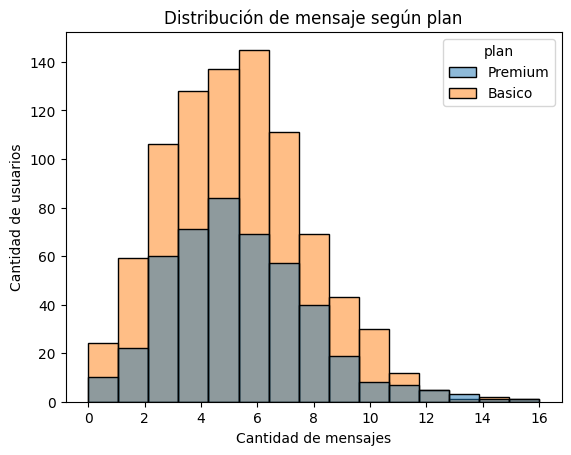

In [161]:
# Histograma para visualizar la cant_mensajes
import seaborn as sns
import matplotlib.pyplot as plt
sns.histplot(
    data=users_2024,
    x="cant_mensajes",
    hue="plan",
    bins=15
)
plt.title("Distribución de mensaje según plan")
plt.xlabel("Cantidad de mensajes")
plt.ylabel("Cantidad de usuarios")
plt.show()


💡Insights: 
La distribución de la cantidad de mensajes presenta una concentración principalmente entre 3 y 8 mensajes, con un máximo alrededor de 5 a 6 mensajes. La distribución presenta una ligera asimetría positiva debido a la presencia de algunos usuarios con una cantidad elevada de mensajes, formando una cola hacia la derecha. El comportamiento de los planes Básico y Premium es similar, aunque el plan Básico presenta una mayor cantidad de usuarios en la mayoría de los intervalos.

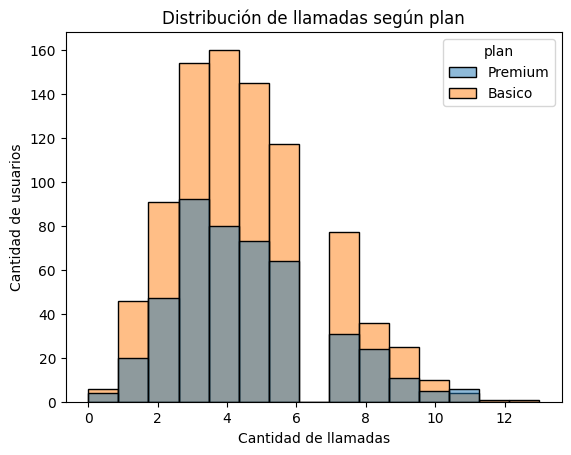

In [162]:
# Histograma para visualizar la cant_llamadas
import seaborn as sns
import matplotlib.pyplot as plt
sns.histplot(
    data=users_2024,
    x="cant_llamadas",
    hue="plan",
    bins=15
    )
plt.title("Distribución de llamadas según plan")
plt.xlabel("Cantidad de llamadas")
plt.ylabel("Cantidad de usuarios")
plt.show()

💡Insights: Los usuarios de ambos planes tienden a realizar principalmente entre 3 y 6 llamadas, destacando una mayor proporción de usuarios del plan Básico en este pico central. Además, se observa una ligera separación (comportamiento bimodal) con un segundo grupo más pequeño que realiza entre 7 y 9 llamadas.

Tipo de distribución: Es una distribución sesgada a la derecha (sesgo positivo), ya que la mayor concentración de llamadas está en valores bajos/medios (con su pico entre 3 y 5) y la cola se alarga hacia la derecha (valores más altos de llamadas).

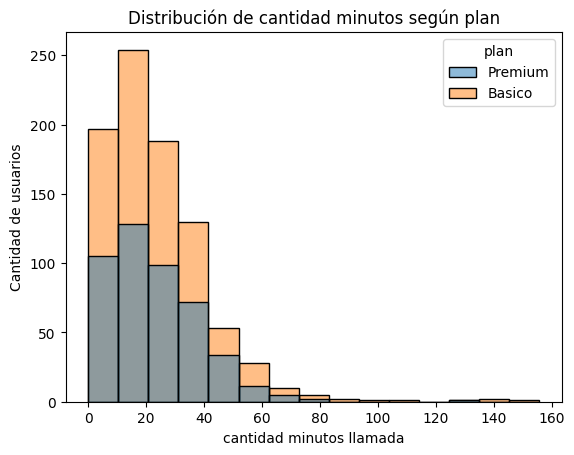

In [163]:
# Histograma para visualizar la cant_minutos_llamada
import seaborn as sns
import matplotlib.pyplot as plt
sns.histplot(
    data=users_2024,
    x="cant_minutos_llamada",
    hue="plan",
    bins=15
    )
plt.title("Distribución de cantidad minutos según plan")
plt.xlabel("cantidad minutos llamada")
plt.ylabel("Cantidad de usuarios")
plt.show()

💡Insights: La gran mayoría de los usuarios (tanto del plan Básico como del Premium) consume un volumen bajo de minutos, concentrándose principalmente entre 0 y 40 minutos por llamada. Dentro del plan Básico hay una proporción significativamente mayor de usuarios en los picos de mayor volumen (especialmente entre 10 y 30 minutos).

Tipo de distribución: Es una distribución sesgada a la derecha (sesgo positivo), ya que el grueso de los datos se agrupa en valores bajos/medios y presenta una larga cola hacia la derecha con consumos ocasionales más altos.

### 5.2 Identificación de Outliers

🎯 **Objetivo:**  
Detectar valores extremos en las variables clave de **uso** y **clientes** que podrían afectar el análisis, y decidir si requieren limpieza o revisión adicional.

**Instrucciones:**  
- Usa **boxplots** para identificar visualmente outliers en las siguientes columnas:  
  - `age` 
  - `cant_mensajes`
  - `cant_llamadas`
  - `total_minutos_llamada`  
- Crea un **for** para generar los 4 boxplots automáticamente.
<br>

- Después de crear los gráfico, responde si **existen o no outliers** en las variables.  
- Si hay outliers, crea otro bucle para calcular los límites de esas columnas usando el **método IQR** y decide qué hacer con ellos.
  - Si solamente hay outliers de un solo lado, no es necesario calcular ambos límites.

**Hint:**
- Dentro del bucle, usa `plt.title(f'Boxplot: {col}')` para que el título cambie acorde a la columna.

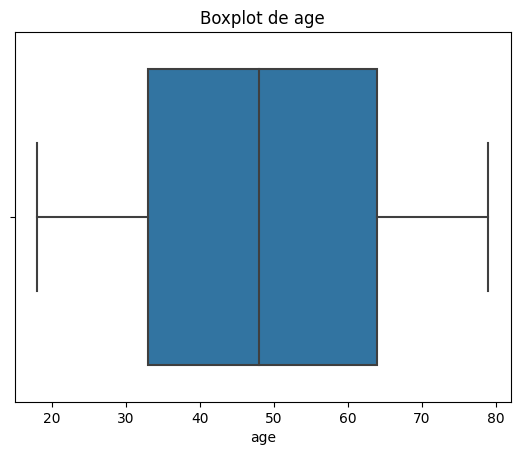

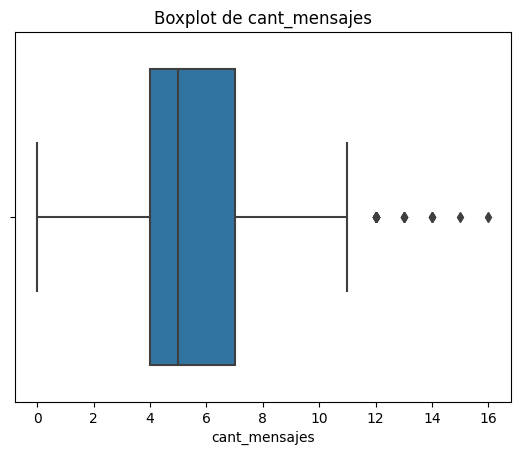

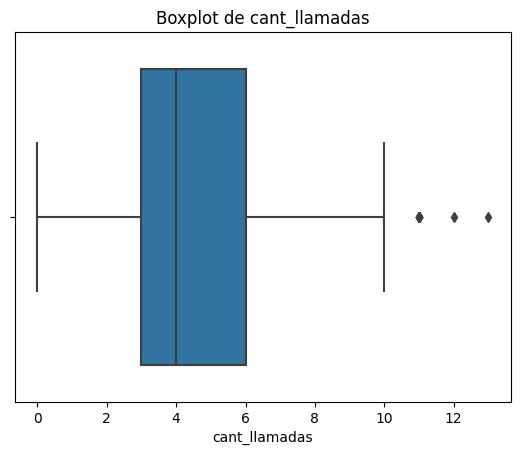

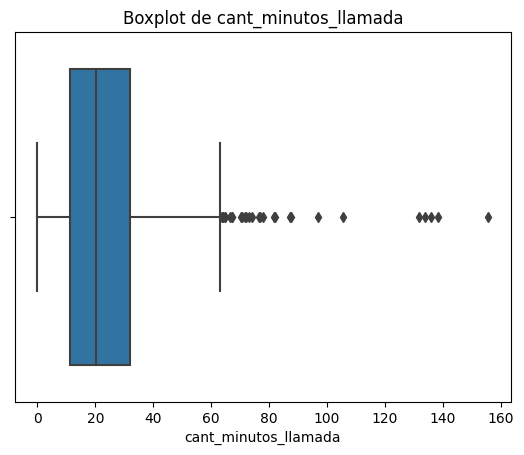

In [164]:
# Visualizando usando BoxPlot 

columnas_numericas = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']
for columna in columnas_numericas:
    sns.boxplot(data=users_2024, x=columna)
    plt.title(f'Boxplot de {columna}')
    plt.xlabel(columna)
    plt.show()

💡Insights: 
- Age: Se abarca desde los 18 hasta casi los 80 años de manera continua y bien distribuida, sin registros extremos que sobrepasen los límites estándar de la regla del IQR.
- cant_mensajes: La distribución de cant_mensajes está sesgada a la derecha (right-skewed), con la gran mayoría de las observaciones entre 0 y 11 mensajes, y un grupo pequeño de valores atípicos entre 12 y 16 mensajes.
- cant_llamadas: La variable cant_llamadas presenta una ligera asimetría hacia la derecha, concentrando el 50% central de las observaciones entre 3 y 6 llamadas, con tres registros atípicos que van de 11 a 13 llamadas.
- cant_minutos_llamada: resenta un marcado sesgo a la derecha (right-skewed). La gran mayoría de las llamadas duran entre 0 y 32 minutos, pero existe una cola larga de usuarios que realizan llamadas inusualmente largas, superando en varios casos las 2 horas de duración.

In [165]:
# Calcular límites con el método IQR
columnas_limites=['age','cant_mensajes','cant_llamadas','cant_minutos_llamada']
for columna in columnas_limites:
    Q1 = users_2024[columna].quantile(0.25)
    Q3 = users_2024[columna].quantile(0.75)
    IQR = Q3 - Q1
    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR
    print(f"\nColumna: {columna}")
    print(f"Q1: {Q1}")
    print(f"Q3: {Q3}")
    print(f"IQR: {IQR}")
    print(f"Límite inferior: {limite_inferior}")
    print(f"Límite superior: {limite_superior}")




Columna: age
Q1: 33.0
Q3: 64.0
IQR: 31.0
Límite inferior: -13.5
Límite superior: 110.5

Columna: cant_mensajes
Q1: 4.0
Q3: 7.0
IQR: 3.0
Límite inferior: -0.5
Límite superior: 11.5

Columna: cant_llamadas
Q1: 3.0
Q3: 6.0
IQR: 3.0
Límite inferior: -1.5
Límite superior: 10.5

Columna: cant_minutos_llamada
Q1: 11.3025
Q3: 32.075
IQR: 20.7725
Límite inferior: -19.856250000000003
Límite superior: 63.23375


In [166]:
# Revisa los limites superiores y el max, para tomar la decisión de mantener los outliers o no
users_2024[columnas_limites].describe()

,age,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,1330.000000,1330.000000,1330.000000,1330.000000
mean,48.414286,5.500000,4.557143,23.314639
std,17.963443,2.382293,2.140329,17.025665
min,18.000000,0.000000,0.000000,0.000000
25%,33.000000,4.000000,3.000000,11.302500
50%,48.000000,5.000000,4.000000,20.185000
75%,64.000000,7.000000,6.000000,32.075000
max,79.000000,16.000000,13.000000,155.690000


💡Insights: 
- cant_mensajes: Para este caso, mantendría los outliers para el analisis. El mantenimiento de estos outliers se justifica porque reflejan un comportamiento real y natural de los usuarios de alto consumo sin provenir de errores de datos; además, al estar el valor máximo (16) muy próximo al límite estadístico (11.5), no distorsionan la distribución y aportan un alto valor de negocio al visibilizar un segmento clave para estrategias de consumo y conversión.
- cant_llamadas: Conservar estos *outliers* en `cant_llamadas` es adecuado porque corresponden al uso legítimo de clientes con alta frecuencia de voz y no a fallos en las mediciones. Dado que el punto máximo (13) está casi pegado al umbral del bigote (10.5), no altera significativamente las métricas, permitiendo además conservar datos estratégicos sobre las preferencias reales de consumo para optimizar la oferta comercial.
- cant_minutos_llamada: 

---

## 🧩Paso 6: Segmentación de Clientes

### 6.1 Segmentación de Clientes Por Uso

🎯 **Objetivo:** Clasificar a cada usuario en un grupo de uso (Bajo uso, Uso medio, Alto uso) basándose en la cantidad de llamadas y mensajes registrados.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_uso` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones de llamadas y mensajes y asigna:
  - `'Bajo uso'` cuando llamadas < 5 y mensajes < 5
  - `'Uso medio'` cuando llamadas < 10 y mensajes < 10
  - `'Alto uso'` para el resto de casos

In [167]:

# Crear columna grupo_uso
user_profile["grupo_uso"] = np.select(
    [
        (user_profile["cant_llamadas"] < 5) & (user_profile["cant_mensajes"] < 5),
        (user_profile["cant_llamadas"] < 10) & (user_profile["cant_mensajes"] < 10)
    ],
    [
        "Bajo uso",
        "Uso medio"
    ],
    default="Alto uso"
)



In [168]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_llamadas,cant_mensajes,cant_minutos_llamada,Tamano_texto,grupo_uso
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,3.0,7.0,23.70,258.0,Uso medio
1,10001,Mateo,Torres,53.0,NaN,2022-01-01 06:34:17.914478619,Basico,NaN,10.0,5.0,33.18,226.0,Alto uso
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,2.0,5.0,10.74,225.0,Uso medio
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,3.0,11.0,8.99,530.0,Alto uso
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,3.0,4.0,8.01,229.0,Bajo uso


### 6.2 Segmentación de Clientes Por Edad

🎯 **Objetivo:**: Clasificar a cada usuario en un grupo por **edad**.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_edad` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones y asigna:
  - `'Joven'` cuando age < 30
  - `'Adulto'` cuando age < 60
  - `'Adulto Mayor'` para el resto de casos

In [169]:
# Crear columna grupo_edad
user_profile["grupo_edad"] = np.select(
    [
        (user_profile["age"]<=30) ,
        (user_profile["age"]>30) & (user_profile["age"] <60)
    ],
    [
        "Joven",
        "Adulto"
    ],
    default="Adulto Mayor"
)

In [170]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_llamadas,cant_mensajes,cant_minutos_llamada,Tamano_texto,grupo_uso,grupo_edad
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,3.0,7.0,23.70,258.0,Uso medio,Adulto
1,10001,Mateo,Torres,53.0,NaN,2022-01-01 06:34:17.914478619,Basico,NaN,10.0,5.0,33.18,226.0,Alto uso,Adulto
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,2.0,5.0,10.74,225.0,Uso medio,Adulto
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,3.0,11.0,8.99,530.0,Alto uso,Adulto Mayor
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,3.0,4.0,8.01,229.0,Bajo uso,Adulto Mayor


### 6.3 Visualización de la Segmentación de Clientes

🎯 **Objetivo:** Visualizar la distribución de los usuarios según los grupos creados: **grupo_uso** y **grupo_edad**.

**Instrucciones:**  
- Crea dos gráficos para las variables categóricas `grupo_uso` y `grupo_edad`.
- Agrega título y etiquetas a los ejes en cada gráfico.

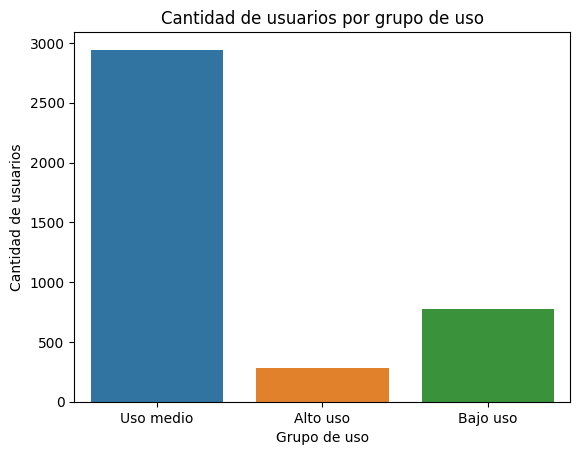

In [171]:
# Visualización de los segmentos por uso
sns.countplot(data=user_profile,x="grupo_uso")
plt.title("Cantidad de usuarios por grupo de uso")
plt.xlabel("Grupo de uso")
plt.ylabel("Cantidad de usuarios")
plt.show()

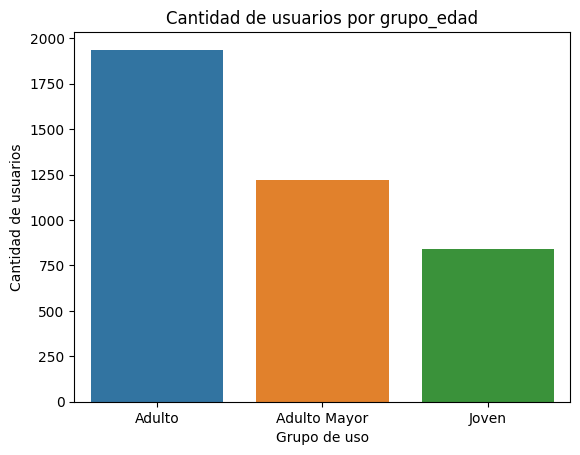

In [172]:
# Visualización de los segmentos por edad
sns.countplot(data=user_profile,x="grupo_edad")
plt.title("Cantidad de usuarios por grupo_edad")
plt.xlabel("Grupo de uso")
plt.ylabel("Cantidad de usuarios")
plt.show()


---
## 🧩Paso 7: Insight Ejecutivo para Stakeholders

🎯 **Objetivo:** Traducir los hallazgos del análisis en conclusiones accionables para el negocio, enfocadas en segmentación, patrones de uso y oportunidades comerciales.

**Preguntas a responder:** 
- ¿Qué problemas tenían originalmemte los datos?¿Qué porcentaje, o cantidad de filas, de esa columna representaban?
- ¿Qué segmentos de clientes identificaste y cómo se comportan según su edad y nivel de uso?  
- ¿Qué segmentos parecen más valiosos para ConnectaTel y por qué?  
- ¿Qué patrones de uso extremo (outliers) encontraste y qué implican para el negocio?
- ¿Qué recomendaciones harías para mejorar la oferta actual de planes o crear nuevos planes basados en los segmentos y patrones detectados?

✍️ **Escribe aquí tu análisis ejecutivo:**



### Análisis ejecutivo

⚠️ **Problemas detectados en los datos**
Problemas detectados en los datos

- Se identificaron varios problemas de calidad. En users, la columna city tenía 469 valores nulos (11,725%), además del sentinel ? y presentaba falta de estandarización entre nombres completos y abreviaturas como CDMX, GDL y MTY. La columna churn_date tenía 3.534 nulos (88,35%), pero estos se interpretaron como usuarios que continúan activos, por lo que no deben eliminarse.
- En usage, date tenía 50 valores nulos (0,125%), mientras que duration tenía 22.076 nulos (55,19%) y length 17.896 nulos (44,74%). Sin embargo, estos últimos no representan necesariamente errores: el análisis mostró que los nulos dependen del tipo de interacción. El 99,93% de los registros de texto no tiene duración y el 99,93% de las llamadas no tiene longitud de mensaje, por lo que se mantuvieron como nulos.
- También se encontraron 28 registros inconsistentes donde aparecían simultáneamente valores en duration y length: 12 llamadas y 16 mensajes. Adicionalmente, se identificó el valor sentinel -999 en age, que distorsionaba la media y la desviación estándar, y 40 registros con fechas de registro de 2026, aunque el periodo esperado llegaba hasta 2024. Estos registros fueron tratados como inconsistencias y las fechas futuras se marcaron como nulas.


🔍 **Segmentos por Edad**

- Se clasificaron los clientes en tres grupos: Joven (hasta 30 años), Adulto (mayores de 30 y menores de 60) y Adulto Mayor (60 años o más). La edad, una vez corregido el sentinel -999, quedó entre 18 y 79 años, con una mediana de 47 años.
- No se observa una diferencia marcada entre Básico y Premium según la edad. La distribución de edades de ambos planes es bastante similar, por lo que la edad por sí sola no parece ser el principal factor que determina la elección del plan.
- Para los usuarios registrados en 2024, la edad promedio fue de aproximadamente 48,4 años, con usuarios entre 18 y 79 años.

📊 **Segmentos por Nivel de Uso**

- Se crearon tres segmentos según la cantidad de llamadas y mensajes: Bajo uso, cuando realizan menos de 5 llamadas y menos de 5 mensajes; Uso medio, cuando realizan menos de 10 llamadas y menos de 10 mensajes; y Alto uso, para el resto de los casos.
- El comportamiento típico se concentra en niveles relativamente bajos de consumo: para los usuarios de 2024, la mediana fue de 4 llamadas, 5 mensajes y 20,19 minutos de llamadas. El máximo alcanzó 13 llamadas, 16 mensajes y 155,69 minutos.
- El plan Básico concentra aproximadamente el 65,6% de los usuarios de 2024, mientras que Premium representa el 34,4%. Esto muestra que el Básico tiene mayor alcance, pero también existe un grupo importante de clientes que utiliza el servicio a un nivel que puede justificar una oferta superior.
- En términos de comportamiento, los clientes de Alto uso representan una oportunidad especialmente interesante, porque realizan más llamadas y/o mensajes y pueden necesitar mayores recursos incluidos en su plan. 


➡️ Esto sugiere que ConnectaTel tiene una base amplia de clientes Básicos y un grupo de usuarios con consumos superiores que puede ser aprovechado para realizar estrategias de motivación a comprar el Premium. La segmentación por uso resulta más útil comercialmente que la edad por sí sola, ya que permite identificar clientes según su comportamiento real de consumo. Además, los outliers pueden representar clientes legítimamente intensivos y, por tanto, oportunidades comerciales en lugar de simples errores que deban eliminarse.


💡 **Recomendaciones**
- Mantener y fortalecer el plan Básico, ya que concentra aproximadamente dos tercios de los usuarios de 2024. Al mismo tiempo, identificar clientes de Alto uso que actualmente están en Básico y ofrecerles incentivos para migrar a Premium. El Premium incluye 500 mensajes, 20 GB y 600 minutos, frente a 100 mensajes, 5 GB y 100 minutos del Básico.
- Implementar estrategias de migración hacia planes superiores, especialmente dirigidas a los usuarios que se acercan o superan los límites del plan Básico. En lugar de ofrecer el plan Premium de manera general, ConnectaTel podría identificar los patrones de consumo de cada cliente y presentar ofertas personalizadas que respondan a sus necesidades.
- Considerar un plan intermedio entre Básico y Premium. Existe una diferencia considerable entre ambos planes: Básico cuesta USD 12 mensuales y Premium USD 25, por lo que un plan intermedio podría captar usuarios cuyo consumo supera el Básico pero todavía no justifica el Premium.
- No eliminar automáticamente los outliers de llamadas y mensajes. Los máximos encontrados —16 mensajes y 13 llamadas— fueron considerados comportamientos reales de usuarios de alto consumo y pueden aportar información para diseñar mejores planes.
- Prestar especial atención al consumo extremo de minutos de llamada: el límite superior calculado mediante IQR fue de 63,23 minutos, mientras que el máximo observado fue de 155,69 minutos. Esto indica la existencia de usuarios con un consumo de voz considerablemente superior al habitual, que podrían requerir ofertas específicas.


---

## 🧩Paso 8 Cargar tu notebook y README a GitHub

🎯 **Objetivo:**  
Entregar tu análisis de forma **profesional**, **documentada** y **versionada**, asegurando que cualquier persona pueda revisar, ejecutar y entender tu trabajo.



### Opción A : Subir archivos desde la interfaz de GitHub (UI)

1. Descarga este notebook (`File → Download .ipynb`).  
2. Entra a tu repositorio en GitHub (por ejemplo `telecom-analysis` o `sprint7-final-project`).  
3. Sube tu notebook **Add file → Upload files**.  

---

### Opción B : Guardar directo desde Google Colab

1. Abre tu notebook en Colab.  
2. Ve a **File → Save a copy in GitHub**.  
3. Selecciona el repositorio y la carpeta correcta (ej: `notebooks/`).  
4. Escribe un mensaje de commit claro, por ejemplo:  
    - `feat: add final ConnectaTel analysis`
    - `agregar version final: Análisis ConnectaTel`
5. Verifica en GitHub que el archivo quedó en el lugar correcto y que el historial de commits se mantenga limpio.

---

Agrega un archivo `README.md` que describa de forma clara:
- el objetivo del proyecto,  
- los datasets utilizados,  
- las etapas del análisis realizadas,  
- cómo ejecutar el notebook (por ejemplo, abrirlo en Google Colab),  
- una breve guía de reproducción.
---

Link a repositorio público del proyecto: `LINK a tu repo aquí`